0         0
1         0
2         0
3         0
4         0
         ..
526246    0
526247    0
526248    0
526249    0
526250    0
Name: disruptive, Length: 526251, dtype: int64
COLS: Index(['Unnamed: 0', 'shot', 'time', 'a_minor', 'beta_n', 'beta_p', 'bt',
       'chisq', 'dbetap_dt', 'dip_dt', 'dip_smoothed', 'dipprog_dt', 'dli_dt',
       'dn_dt', 'dprad_dt', 'dwmhd_dt', 'greenwald_fraction', 'i_efc', 'ip',
       'ip_error', 'ip_prog', 'kappa', 'kappa_area', 'li', 'lower_gap', 'n_e',
       'n_equal_1_mode', 'n_equal_1_normalized', 'n_equal_1_phase',
       'n_over_ncrit', 'ne_peaking', 'p_icrf', 'p_input', 'p_lh', 'p_oh',
       'p_rad', 'prad_peaking', 'pressure_peaking', 'q0', 'q95', 'qstar',
       'radiated_fraction', 'rmagx', 'ssep', 'sxr', 'tau_rad',
       'te_core_vs_avg_ece', 'te_edge_vs_avg_ece', 'te_peaking', 'te_width',
       'te_width_ece', 'time_until_disrupt', 'tribot', 'tritop', 'upper_gap',
       'v_loop', 'v_loop_efit', 'v_surf', 'v_z', 'wmhd', 'z_error', 'z_p

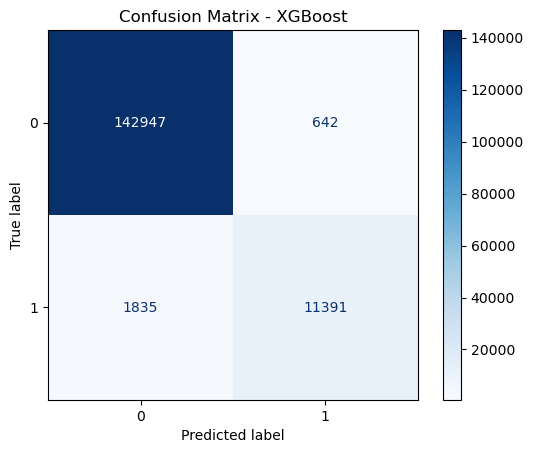

               feature  importance
30         v_loop_efit    0.461263
35              z_prog    0.038202
31              v_surf    0.029903
16        n_over_ncrit    0.029848
21                 q95    0.029787
7   greenwald_fraction    0.024065
9                   ip    0.021474
24                ssep    0.017311
27              tribot    0.016677
13                  li    0.016360
ROC AUC Score: 0.9914


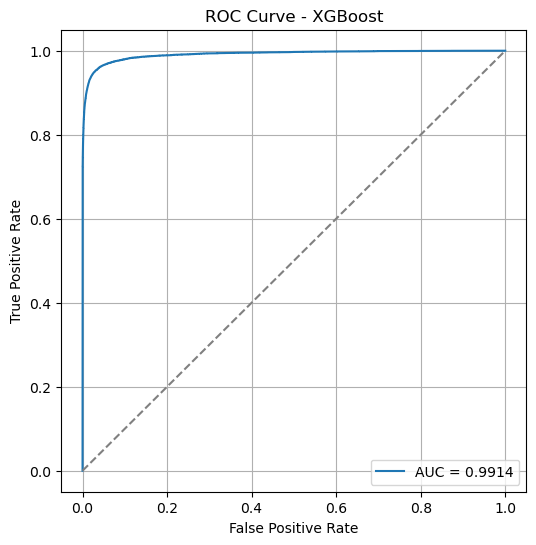

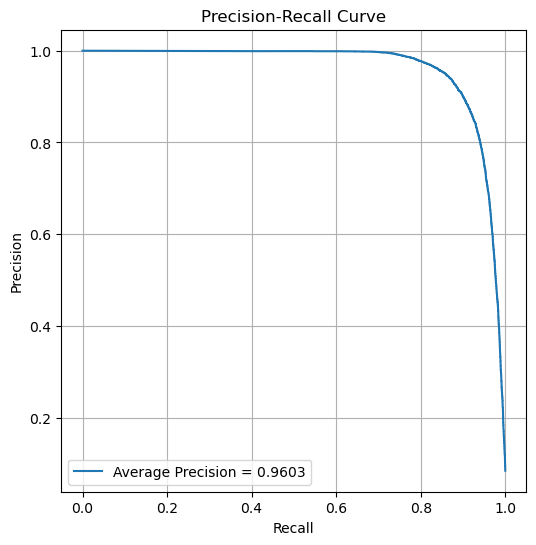

In [1]:
import torch
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from utils.createLoader import createLoaders


##############################


### Constants
#DATA_PATH = "./data/raw_data/cmod.csv";
DATA_PATH = "./data/cmod_clean_200ms.csv"
CONFIG_PATH = "class_ti.json"

####


pd.set_option("display.max_columns", None);
config = None
### Config
with open(CONFIG_PATH, 'r', encoding = 'utf-8') as file: 
    config = json.load(file)

#################################

# Step 1: Get data and prune unnecessary columns
# Step 2: Plot Data (optional)
# Step 3: DataSet
# Step 4: Split Data
# Step 5: DataLoader

#print(config["dataloader"]["ignore_columns"]) #just to check which columns are being ignored

#class_ti_train, class_ti_test, class_ti_val = createLoaders(config, dataset=pd.read_csv(DATA_PATH,sep=',',index_col=None));

# Step 6: Model

########################### XGBOOST Model #####################################################
#from sklearn.model_selection import train_test_split
#from xgboost import XGBClassifier

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#model = XGBClassifier(eval_metric="logloss", random_state=42)
#model.fit(X_train, y_train)
#y_pred = model.predict(X_test)

##############################################

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay

#load the dataset
df_xgb = pd.read_csv(DATA_PATH, sep=",")
print(df_xgb['disruptive'])
print("COLS:",df_xgb.columns)

df_xgb = df_xgb.replace([np.inf, -np.inf], np.nan) #clean the data
print(config['dataloader']['ignore_columns'])

df_xgb = df_xgb.drop(columns=config["dataloader"]["ignore_columns"], errors="ignore") #drop the ignored columns
df_xgb = df_xgb.dropna() #drop the NaNs

print(df_xgb.columns)

#define label and features
label_col = config["dataloader"]["label_column"]
y = df_xgb[label_col].values
X = df_xgb.drop(columns=[label_col])

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#making weights- i.e. mistakes with classifying the disruptive ones are more "costly" than mistakes with classifying the non-disruptive ones
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
scale_pos_weight = num_neg / num_pos
print(scale_pos_weight)
#doing this increased the precision for the disruptive cases from 0.78 to 0.82

#making the model
model = XGBClassifier(eval_metric="logloss",random_state=42, scale_pos_weight=scale_pos_weight, n_estimators=1000) 
#trying to explictly specify n_estimators (default is 100) to see if that works
#explicitly specifying n_estimators = 300 increased it from 0.82 to 0.89; n_estimators = 400 and = 500 increased it to 0.90; 600, 800, 1000 increased it to 0.91
#adding an explicit max_depth rate of 0.4 made it worse (0.76)
#adding an explicit learning rate of 0.01, 0.03, 0.05, and 0.09 made it worse (0.77 or 0.78)
model.fit(X_train, y_train)
y_pred = model.predict(X_test) #this uses a threshold of 0.5

##############metrics####################

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#accuracy score and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

#conf_matrix = confusion_matrix(y_test, y_pred) #confusion matrix
#plt.figure(figsize=(5, 4))
#plt.imshow(conf_matrix, cmap="Blues")
#plt.title("Confusion Matrix - XGBoost")
#plt.colorbar()
#plt.xlabel("Predicted")
#plt.ylabel("Actual")
#plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

#Feature importance
print(importance.sort_values("importance", ascending=False).head(10))

#ROC
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

#and plot it
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

#precision-recall curve

from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avgpos = average_precision_score(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"Average Precision = {avgpos:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

##############################################################################################

# Step 7: Config json

# Step 8: Trainer

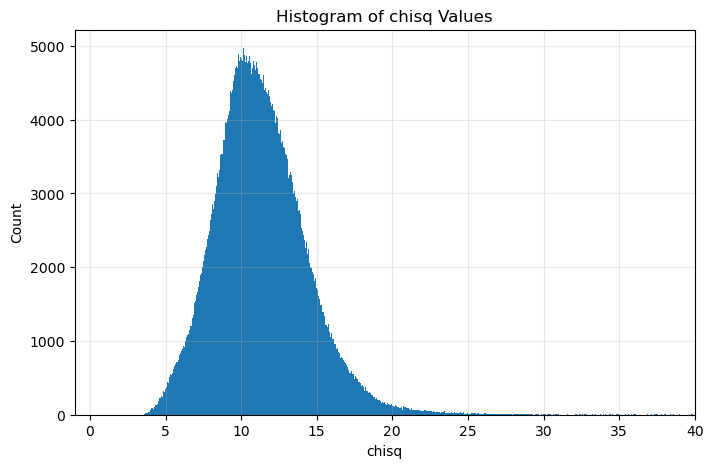

In [16]:
#plotting to check the dip_dt vs. the dip_smoothed

#plt.figure(figsize=(10, 4))
#plt.plot(df_xgb["dip_dt"])
#plt.title("dip_dt")
#plt.grid(True)
#plt.show()

#plt.figure(figsize=(10, 4))
#plt.plot(df_xgb["dip_smoothed"])
#plt.title("dip_smoothed")
#plt.grid(True)
#plt.show()

#####################
#plotting chisq
#adjust the number of bins until you get what you need

#value vs. amount
#histogram of chisq values

#plt.figure(figsize=(8,5))
#plt.hist(df_xgb["chisq"], bins=100000)

#plt.xlim(-1, 40)

#plt.title("Histogram of chisq Values")
#plt.xlabel("chisq")
#plt.ylabel("Count")

#plt.grid(True, alpha=0.3)
#plt.show()